Installing dependencies

In [1]:
!pip install pennylane -q


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 52.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 937.5/937.5 kB 53.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.5/25.5 MB 63.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 84.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.2/167.2 kB 16.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 73.0 MB/s eta 0:00:00


In [11]:
!pip install pennylane-lightning[gpu] -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 924.6/924.6 kB 16.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.2/73.2 MB 13.6 MB/s eta 0:00:00


Imports

In [2]:
import pennylane as qml
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import os
import random
from PIL import Image

Global config

In [3]:
SEED = 42
torch.manual_seed(SEED)
random.seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

N_QUBITS = 8
BATCH_SIZE = 32
N_EPOCHS = 30
LR = 0.001
N_TRAIN = 200
N_TEST = 50
IMG_SIZE = 8
N_BRAIN_CLASSES = 4

Using device: cuda


QCNN circuit definition

In [14]:
if torch.cuda.is_available():
    # Use Lightning-GPU for PennyLane if CUDA is available
    dev = qml.device("lightning.gpu", wires=N_QUBITS)
else:
    # Fallback to default.qubit if no CUDA device is found
    dev = qml.device("default.qubit", wires=N_QUBITS)

n_block_wires = 2
n_params_block = 2

def block(weights, wires):
    qml.RY(weights[0], wires=wires[0])
    qml.RY(weights[1], wires=wires[1])
    qml.CNOT(wires=[wires[0], wires[1]])

n_blocks = qml.MERA.get_n_blocks(range(N_QUBITS), n_block_wires)

@qml.qnode(dev, interface="torch")
def qcnn_circuit(inputs, weights):
    qml.AngleEmbedding(inputs, wires=range(N_QUBITS), rotation="Y")
    qml.MERA(
        wires=range(N_QUBITS),
        n_block_wires=n_block_wires,
        block=block,
        n_params_block=n_params_block,
        template_weights=weights
    )
    return [qml.expval(qml.PauliZ(i)) for i in range(N_QUBITS)]

weight_shapes = {"weights": (n_blocks, n_params_block)}
print(f"MERA blocks: {n_blocks}, trainable params: {n_blocks * n_params_block}")

MERA blocks: 13, trainable params: 26


Model definition

In [5]:
class QCNNClassifier(nn.Module):
    def __init__(self, n_classes):
        super().__init__()
        self.qlayer = qml.qnn.TorchLayer(qcnn_circuit, weight_shapes)
        self.fc = nn.Linear(N_QUBITS, n_classes)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = x[:, :N_QUBITS]
        x = self.qlayer(x)
        x = self.fc(x)
        return x

Helper Function

In [6]:
def add_gaussian_noise(data, noise_std):
    noisy = []
    for img, label in data:
        if noise_std > 0:
            img = torch.clamp(img + torch.randn_like(img) * noise_std, 0.0, 1.0)
        noisy.append((img, label))
    return noisy

def collate_fn(batch):
    imgs, labels = zip(*batch)
    return torch.stack(imgs), torch.tensor(labels)

def get_subset(dataset, n_samples, n_classes):
    indices = []
    class_counts = {i: 0 for i in range(n_classes)}
    per_class = n_samples // n_classes
    for idx in range(len(dataset)):
        _, label = dataset[idx]
        label = int(label)
        if label < n_classes and class_counts[label] < per_class:
            indices.append(idx)
            class_counts[label] += 1
        if sum(class_counts.values()) >= n_samples:
            break
    return indices

def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        out = model(imgs)
        loss = criterion(out, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * imgs.size(0)
        correct += (out.argmax(1) == labels).sum().item()
        total += imgs.size(0)
    return total_loss / total, correct / total

def eval_epoch(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            out = model(imgs)
            loss = criterion(out, labels)
            total_loss += loss.item() * imgs.size(0)
            correct += (out.argmax(1) == labels).sum().item()
            total += imgs.size(0)
    return total_loss / total, correct / total

def run_experiment(train_data, test_data, n_classes, dataset_name, noise_label):
    train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
    test_loader = DataLoader(test_data, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)
    model = QCNNClassifier(n_classes=n_classes).to(device)
    optimizer = optim.Adam(model.parameters(), lr=LR)
    criterion = nn.CrossEntropyLoss()
    train_losses, test_losses, train_accs, test_accs = [], [], [], []
    for epoch in range(N_EPOCHS):
        tr_loss, tr_acc = train_epoch(model, train_loader, optimizer, criterion)
        te_loss, te_acc = eval_epoch(model, test_loader, criterion)
        train_losses.append(tr_loss)
        test_losses.append(te_loss)
        train_accs.append(tr_acc)
        test_accs.append(te_acc)
        if (epoch + 1) % 5 == 0:
            print(f"  [{dataset_name} | Noise={noise_label}] Epoch {epoch+1}/{N_EPOCHS} | "
                  f"Train Loss: {tr_loss:.4f} Acc: {tr_acc:.4f} | "
                  f"Test Loss: {te_loss:.4f} Acc: {te_acc:.4f}")
    return {
        "train_losses": train_losses,
        "test_losses": test_losses,
        "train_accs": train_accs,
        "test_accs": test_accs,
        "final_test_acc": test_accs[-1]
    }

Loading MNIST and F-MNIST

In [7]:
mnist_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.Grayscale(),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

mnist_train_full = datasets.MNIST(root="./data", train=True, download=True, transform=mnist_transform)
mnist_test_full  = datasets.MNIST(root="./data", train=False, download=True, transform=mnist_transform)
mnist_train_raw  = [mnist_train_full[i] for i in get_subset(mnist_train_full, N_TRAIN, 10)]
mnist_test_raw   = [mnist_test_full[i]  for i in get_subset(mnist_test_full,  N_TEST,  10)]

fmnist_train_full = datasets.FashionMNIST(root="./data", train=True, download=True, transform=mnist_transform)
fmnist_test_full  = datasets.FashionMNIST(root="./data", train=False, download=True, transform=mnist_transform)
fmnist_train_raw  = [fmnist_train_full[i] for i in get_subset(fmnist_train_full, N_TRAIN, 10)]
fmnist_test_raw   = [fmnist_test_full[i]  for i in get_subset(fmnist_test_full,  N_TEST,  10)]

print(f"MNIST     — train: {len(mnist_train_raw)}, test: {len(mnist_test_raw)}")
print(f"F-MNIST   — train: {len(fmnist_train_raw)}, test: {len(fmnist_test_raw)}")

100%|██████████| 9.91M/9.91M [00:00<00:00, 44.4MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.62MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 14.1MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 3.46MB/s]
100%|██████████| 26.4M/26.4M [00:01<00:00, 17.6MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 301kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 5.59MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 24.5MB/s]


MNIST     — train: 200, test: 50
F-MNIST   — train: 200, test: 50


Loading Brain Tumor MRI dataset

In [8]:
!unzip -q brain_tumour_dataset.zip
MRI_DIR = '/content'

brain_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.Grayscale(),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

class BrainTumorDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.transform = transform
        self.samples = []
        self.class_to_idx = {}
        classes = sorted([d for d in os.listdir(root_dir) if os.path.isdir(os.path.join(root_dir, d))])
        for idx, cls in enumerate(classes):
            self.class_to_idx[cls] = idx
            for fname in os.listdir(os.path.join(root_dir, cls)):
                if fname.lower().endswith(('.jpg', '.jpeg', '.png')):
                    self.samples.append((os.path.join(root_dir, cls, fname), idx))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        img = Image.open(img_path).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, label

brain_train_full = BrainTumorDataset(os.path.join(MRI_DIR, "Training"), transform=brain_transform)
brain_test_full  = BrainTumorDataset(os.path.join(MRI_DIR, "Testing"),  transform=brain_transform)

print(f"Classes: {brain_train_full.class_to_idx}")
brain_train_raw = [brain_train_full[i] for i in get_subset(brain_train_full, N_TRAIN, N_BRAIN_CLASSES)]
brain_test_raw  = [brain_test_full[i]  for i in get_subset(brain_test_full,  N_TEST,  N_BRAIN_CLASSES)]
print(f"Brain Tumor — train: {len(brain_train_raw)}, test: {len(brain_test_raw)}")

Classes: {'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}
Brain Tumor — train: 200, test: 48


Running all experiments

In [15]:
NOISE_LEVELS = [0.0, 0.05, 0.10]
NOISE_LABELS  = ["0%", "5%", "10%"]

results = {}

for noise_std, noise_label in zip(NOISE_LEVELS, NOISE_LABELS):
    print(f"\n{'='*60}")
    print(f"Gaussian Noise: {noise_label}")
    print(f"{'='*60}")

    results[f"MNIST_{noise_label}"] = run_experiment(
        add_gaussian_noise(mnist_train_raw, noise_std),
        add_gaussian_noise(mnist_test_raw,  noise_std),
        10, "MNIST", noise_label
    )
    results[f"FMNIST_{noise_label}"] = run_experiment(
        add_gaussian_noise(fmnist_train_raw, noise_std),
        add_gaussian_noise(fmnist_test_raw,  noise_std),
        10, "F-MNIST", noise_label
    )
    results[f"BrainTumor_{noise_label}"] = run_experiment(
        add_gaussian_noise(brain_train_raw, noise_std),
        add_gaussian_noise(brain_test_raw,  noise_std),
        N_BRAIN_CLASSES, "BrainTumor", noise_label
    )


Gaussian Noise: 0%
  [MNIST | Noise=0%] Epoch 5/30 | Train Loss: 2.3335 Acc: 0.1000 | Test Loss: 2.3327 Acc: 0.1000
  [MNIST | Noise=0%] Epoch 10/30 | Train Loss: 2.3246 Acc: 0.1000 | Test Loss: 2.3250 Acc: 0.1000
  [MNIST | Noise=0%] Epoch 15/30 | Train Loss: 2.3185 Acc: 0.1000 | Test Loss: 2.3199 Acc: 0.1000
  [MNIST | Noise=0%] Epoch 20/30 | Train Loss: 2.3138 Acc: 0.1000 | Test Loss: 2.3164 Acc: 0.1000
  [MNIST | Noise=0%] Epoch 25/30 | Train Loss: 2.3099 Acc: 0.1000 | Test Loss: 2.3131 Acc: 0.1000
  [MNIST | Noise=0%] Epoch 30/30 | Train Loss: 2.3070 Acc: 0.0950 | Test Loss: 2.3111 Acc: 0.0800
  [F-MNIST | Noise=0%] Epoch 5/30 | Train Loss: 2.3539 Acc: 0.1000 | Test Loss: 2.3420 Acc: 0.1000
  [F-MNIST | Noise=0%] Epoch 10/30 | Train Loss: 2.3229 Acc: 0.1000 | Test Loss: 2.3111 Acc: 0.1000
  [F-MNIST | Noise=0%] Epoch 15/30 | Train Loss: 2.2996 Acc: 0.1000 | Test Loss: 2.2886 Acc: 0.1000
  [F-MNIST | Noise=0%] Epoch 20/30 | Train Loss: 2.2807 Acc: 0.1000 | Test Loss: 2.2703 Acc: 0

Printing accuracy summary table

In [16]:
print("\n" + "="*55)
print(f"{'Dataset':<25} {'Noise':>6}  {'Test Accuracy':>13}")
print("="*55)
for ds in ["MNIST", "FMNIST", "BrainTumor"]:
    for nl in NOISE_LABELS:
        acc = results[f"{ds}_{nl}"]["final_test_acc"] * 100
        print(f"{ds:<25} {nl:>6}  {acc:>12.2f}%")
print("="*55)


Dataset                    Noise  Test Accuracy
MNIST                         0%          8.00%
MNIST                         5%         10.00%
MNIST                        10%         10.00%
FMNIST                        0%         22.00%
FMNIST                        5%         10.00%
FMNIST                       10%         12.00%
BrainTumor                    0%         33.33%
BrainTumor                    5%         25.00%
BrainTumor                   10%         25.00%


Plotting loss curves

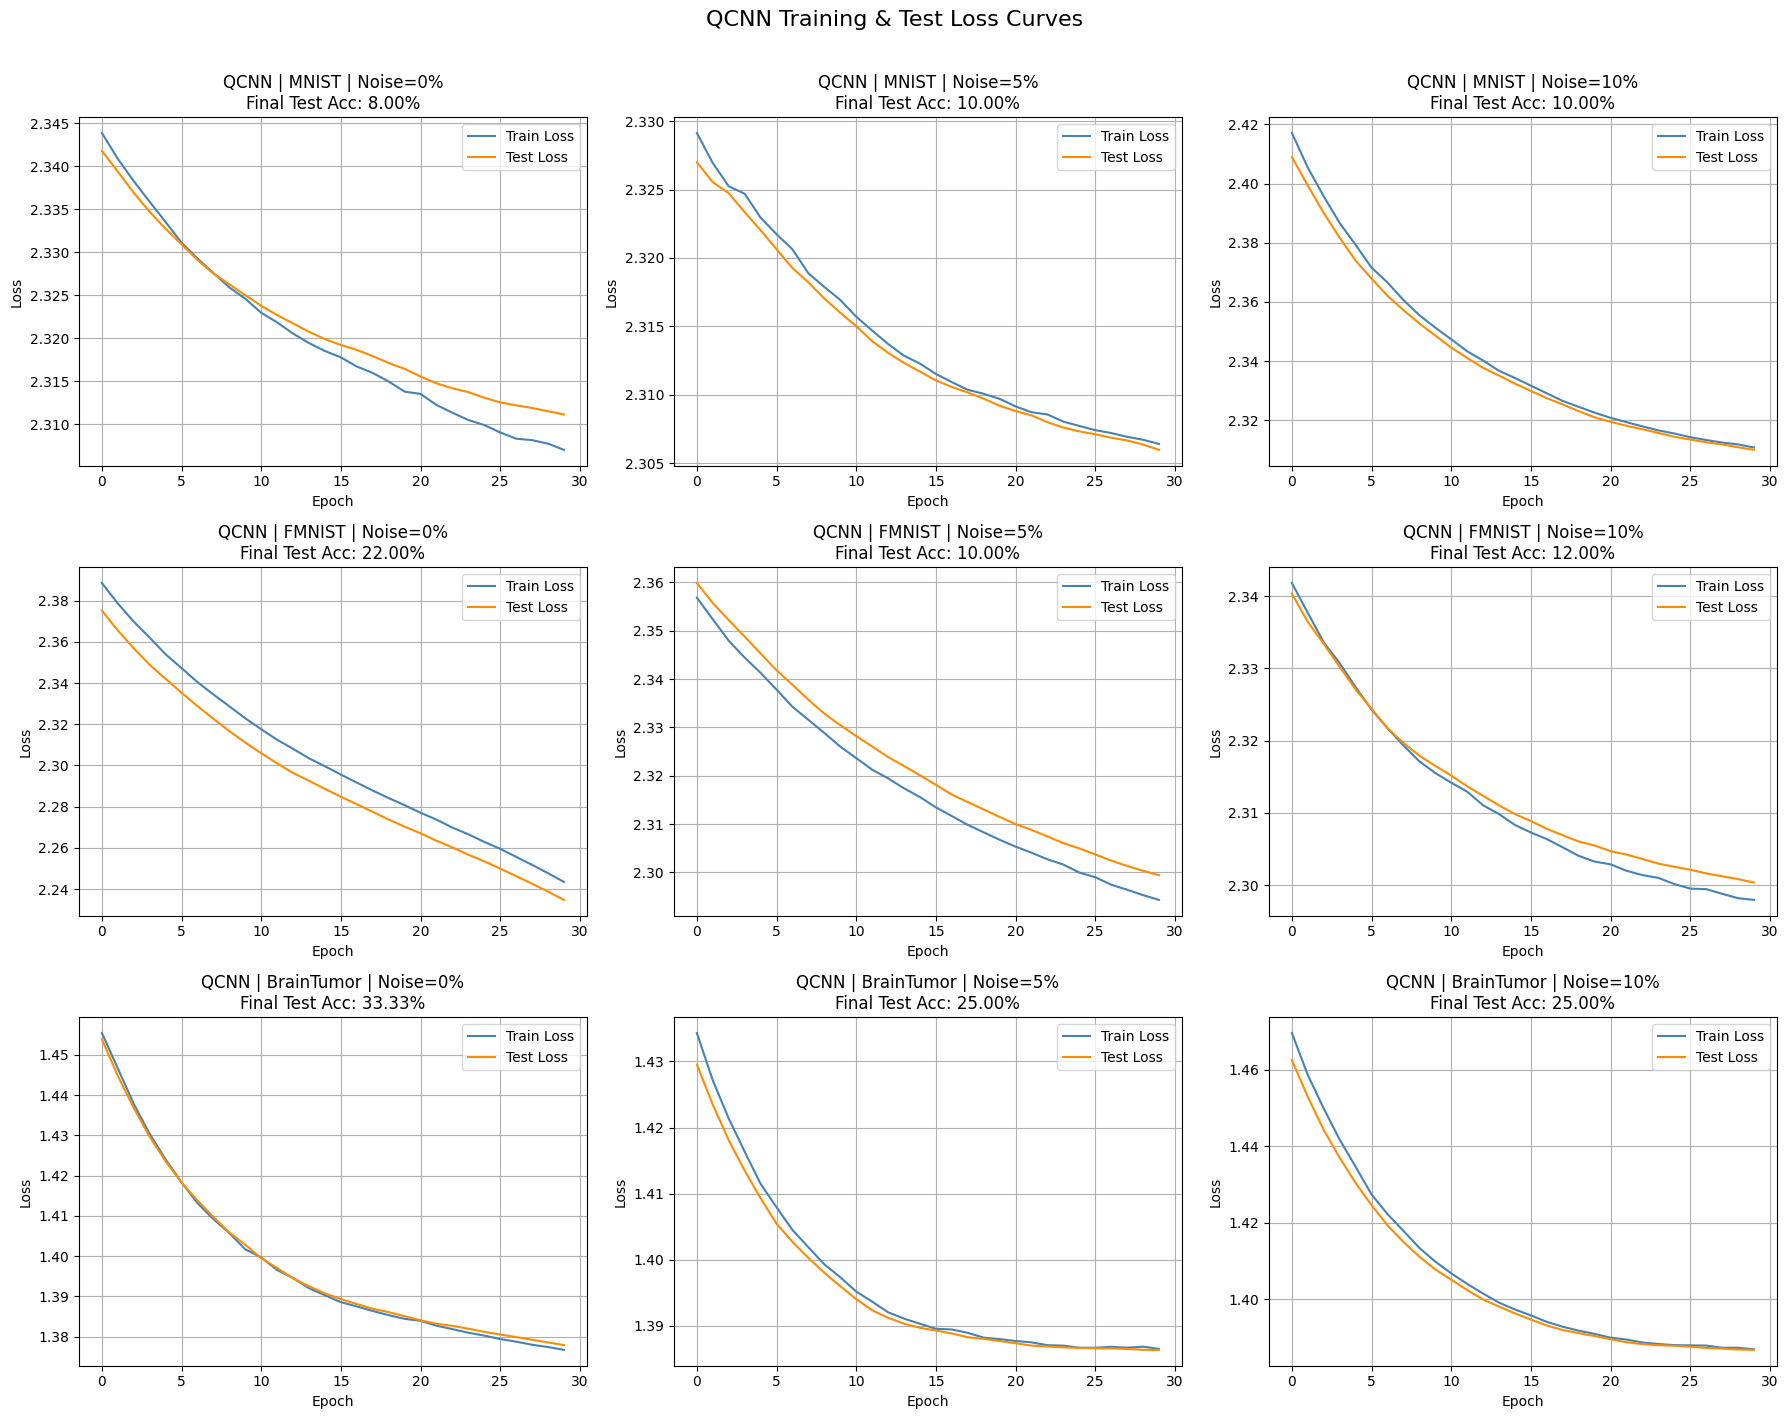

In [17]:
fig, axes = plt.subplots(3, 3, figsize=(18, 14))
ds_names = ["MNIST", "FMNIST", "BrainTumor"]

for row, ds in enumerate(ds_names):
    for col, nl in enumerate(NOISE_LABELS):
        key = f"{ds}_{nl}"
        ax = axes[row][col]
        ax.plot(results[key]["train_losses"], label="Train Loss", color="steelblue")
        ax.plot(results[key]["test_losses"],  label="Test Loss",  color="darkorange")
        ax.set_title(f"QCNN | {ds} | Noise={nl}\nFinal Test Acc: {results[key]['final_test_acc']*100:.2f}%")
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Loss")
        ax.legend()
        ax.grid(True)

plt.suptitle("QCNN Training & Test Loss Curves", fontsize=16, y=1.01)
plt.tight_layout()
plt.savefig("qcnn_loss_curves.png", dpi=150, bbox_inches="tight")
plt.show()

Plotting accuracy bar charts

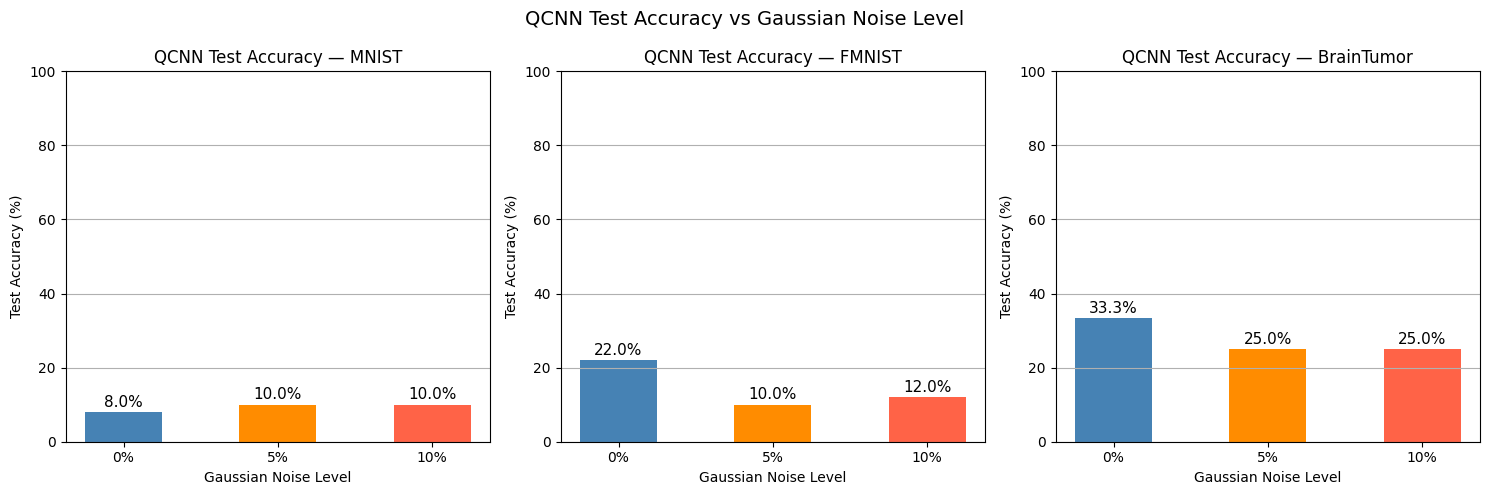

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for col, ds in enumerate(ds_names):
    accs = [results[f"{ds}_{nl}"]["final_test_acc"] * 100 for nl in NOISE_LABELS]
    bars = axes[col].bar(NOISE_LABELS, accs, color=["steelblue", "darkorange", "tomato"], width=0.5)
    axes[col].set_title(f"QCNN Test Accuracy — {ds}")
    axes[col].set_xlabel("Gaussian Noise Level")
    axes[col].set_ylabel("Test Accuracy (%)")
    axes[col].set_ylim(0, 100)
    for bar, v in zip(bars, accs):
        axes[col].text(bar.get_x() + bar.get_width() / 2, v + 1.5, f"{v:.1f}%", ha="center", fontsize=11)
    axes[col].grid(axis="y")

plt.suptitle("QCNN Test Accuracy vs Gaussian Noise Level", fontsize=14)
plt.tight_layout()
plt.savefig("qcnn_accuracy_bars.png", dpi=150, bbox_inches="tight")
plt.show()